# E-Commerce Customer Behaviour & Purchase Prediction

This notebook follows the requested structure: data cleaning, EDA, preprocessing, classification models with evaluation, customer segmentation, and purchase behaviour analysis.

**A note on the data.** The requested outline (age/income distributions, customer satisfaction, device preferences, regional analysis, loyalty programme) assumes a customer-demographics dataset. The uploaded `cleaned_recentdata.csv` is actually an **e-commerce clickstream log** — one row per `view`/`cart`/`purchase` event, with `product_id`, `category_code`, `brand`, `price`, `user_id`, `user_session`, and `event_time`. There is no age, income, satisfaction, device, or region column in the file.

To keep the notebook genuinely useful rather than faking columns that don't exist, each section below is adapted to what the data actually supports, using the closest realistic equivalent:

| Requested | Adapted to this dataset |
|---|---|
| Purchase distribution | Event type distribution (view/cart/purchase) & price distribution |
| Age / Income distribution | *Not available — not applicable to clickstream data* |
| Product categories | Category distribution from `category_code` |
| Customer satisfaction | *Not available — not applicable to clickstream data* |
| ML target | Predicting **purchase vs. non-purchase** from event features |
| Device preferences / Regional analysis / Loyalty programme | *Not available — no device, geo, or loyalty fields in the file* |
| Purchase frequency | Purchases per user, purchases over time |

If a richer dataset with those demographic/behavioural fields is available, this notebook can be re-pointed at it and those sections restored as originally specified.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42


## 2. Load Dataset

In [2]:
df = pd.read_csv('cleaned_recentdata.csv')
print(df.shape)
df.head()


(99884, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00+00:00,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00+00:00,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01+00:00,view,17302664,2053013553853497655,Unknown,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01+00:00,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01+00:00,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 99884 entries, 0 to 99883
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     99884 non-null  str    
 1   event_type     99884 non-null  str    
 2   product_id     99884 non-null  int64  
 3   category_id    99884 non-null  int64  
 4   category_code  99884 non-null  str    
 5   brand          99884 non-null  str    
 6   price          99884 non-null  float64
 7   user_id        99884 non-null  int64  
 8   user_session   99884 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 6.9 MB


## 3. Data Cleaning

### 3.1 Missing values

In [4]:
df.isna().sum()


event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64

`category_code` uses the string `"Unknown"` for unlabelled products rather than a null — let's confirm, and treat it as a real category level (dropping it would discard ~a third of the rows).

In [5]:
(df['category_code'] == 'Unknown').sum(), (df['category_code'] == 'Unknown').mean()


(np.int64(33063), np.float64(0.3310139762124064))

### 3.2 Duplicates

In [6]:
dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")


Fully duplicated rows: 0


Shape after dropping duplicates: (99884, 9)


### 3.3 Data types

In [7]:
df['event_time'] = pd.to_datetime(df['event_time'])
df['event_type'] = df['event_type'].astype('category')
df['brand'] = df['brand'].astype(str)
df.dtypes


event_time       datetime64[us, UTC]
event_type                  category
product_id                     int64
category_id                    int64
category_code                    str
brand                            str
price                        float64
user_id                        int64
user_session                     str
dtype: object

### 3.4 Outlier detection

Using the IQR rule on `price`, the main continuous variable in this dataset.

IQR bounds: [-377.44, 798.53]
Outlier rows by IQR rule: 8367 (8.4%)


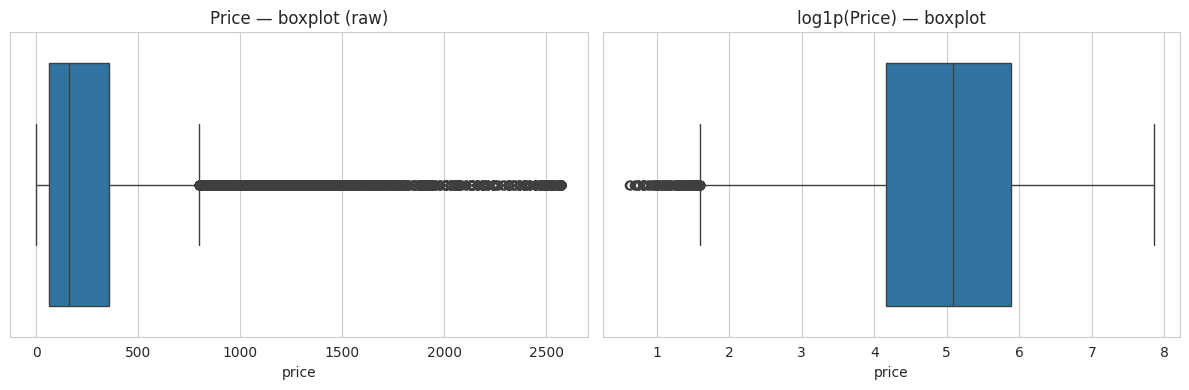

In [8]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_outliers = ((df['price'] < lower_bound) | (df['price'] > upper_bound)).sum()
print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outlier rows by IQR rule: {n_outliers} ({n_outliers/len(df):.1%})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['price'], ax=ax[0])
ax[0].set_title('Price — boxplot (raw)')
sns.boxplot(x=np.log1p(df['price']), ax=ax[1])
ax[1].set_title('log1p(Price) — boxplot')
plt.tight_layout()
plt.show()


These "outliers" are legitimate, just expensive products (e.g. appliances vs. accessories), not data errors — so we keep them rather than dropping rows, but we will use tree-based models (robust to scale/outliers) alongside scaled linear models for the classification task later.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Purchase distribution

(event type distribution, standing in for the requested "purchase distribution")

event_type
view        97535
purchase     1316
cart         1033
Name: count, dtype: int64


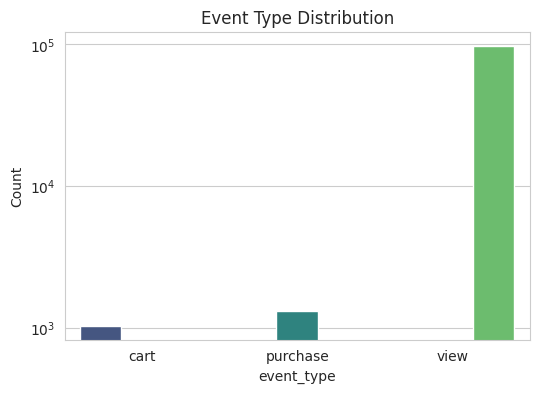

In [9]:
event_counts = df['event_type'].value_counts()
print(event_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=event_counts.index, y=event_counts.values, hue=event_counts.index, palette='viridis', legend=False)
plt.title('Event Type Distribution')
plt.ylabel('Count')
plt.yscale('log')
plt.show()


Price distribution, split by event type:

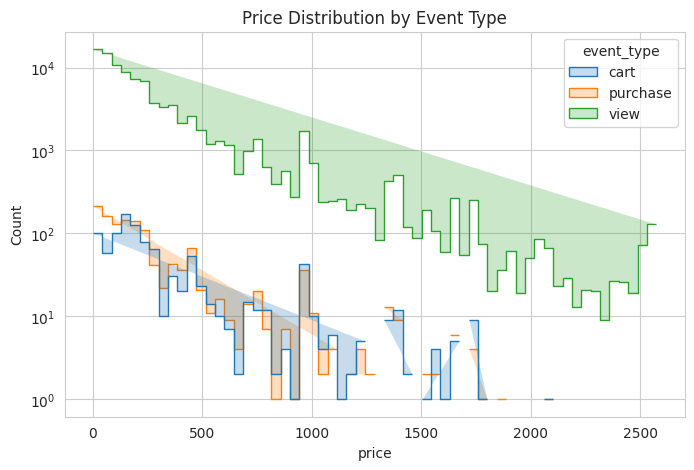

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='price', hue='event_type', bins=60, log_scale=(False, True), element='step')
plt.title('Price Distribution by Event Type')
plt.show()


### 4.2 Age distribution
*Not applicable — no `age` field exists in this dataset.*

### 4.3 Income distribution
*Not applicable — no `income` field exists in this dataset.*

### 4.4 Product categories

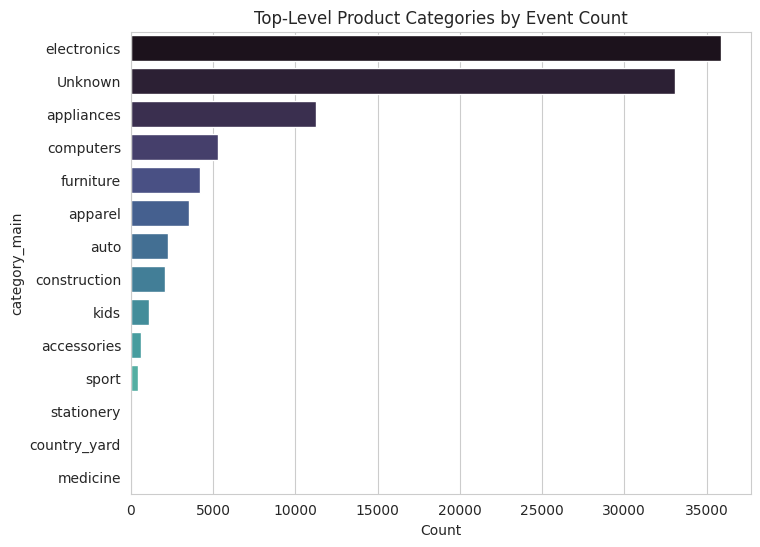

In [11]:
df['category_main'] = df['category_code'].apply(lambda x: x.split('.')[0] if x != 'Unknown' else 'Unknown')

top_categories = df['category_main'].value_counts().head(15)
plt.figure(figsize=(8,6))
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='mako', legend=False)
plt.title('Top-Level Product Categories by Event Count')
plt.xlabel('Count')
plt.show()


### 4.5 Customer satisfaction
*Not applicable — no satisfaction/rating field exists in this dataset.*

### 4.6 Correlation heatmap

Only a few numeric fields exist natively; we add encoded/derived numeric features first so the heatmap is informative.

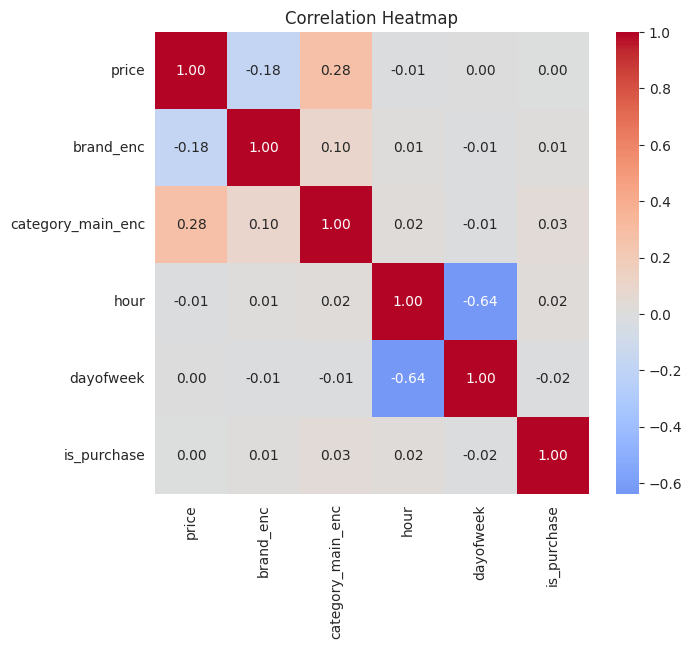

In [12]:
df['hour'] = df['event_time'].dt.hour
df['dayofweek'] = df['event_time'].dt.dayofweek
df['is_purchase'] = (df['event_type'] == 'purchase').astype(int)

le_brand = LabelEncoder()
df['brand_enc'] = le_brand.fit_transform(df['brand'])

le_cat = LabelEncoder()
df['category_main_enc'] = le_cat.fit_transform(df['category_main'])

numeric_cols = ['price', 'brand_enc', 'category_main_enc', 'hour', 'dayofweek', 'is_purchase']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


## 5. Data Preprocessing

**Modelling task:** since there's no demographic target to predict, we build the natural supervised task this data does support — classifying whether a browsing event converts to a **purchase** (`is_purchase`), using `price`, `brand`, `category`, and time-of-day/week as features.

### 5.1 Label Encoding

Already applied above for `brand` and `category_main` (`brand_enc`, `category_main_enc`) — required since both are high-cardinality strings.

### 5.2 One-Hot Encoding (where appropriate)

`dayofweek` is low-cardinality and not ordinal in a way linear models should assume — one-hot encode it for the linear/SVM models.

In [13]:
dow_ohe = pd.get_dummies(df['dayofweek'], prefix='dow')
model_df = pd.concat([df[['price', 'brand_enc', 'category_main_enc', 'hour', 'is_purchase']], dow_ohe], axis=1)
model_df.head()


,price,brand_enc,category_main_enc,hour,is_purchase,dow_1,dow_4
0,489.07,1632,8,0,0,False,True
1,293.65,755,3,0,0,False,True
2,28.31,361,0,0,0,False,True
3,712.87,884,3,0,0,False,True
4,183.27,1632,8,0,0,False,True


### 5.3 Feature Scaling & 5.4 Train/Test Split

In [14]:
feature_cols = [c for c in model_df.columns if c != 'is_purchase']
X = model_df[feature_cols]
y = model_df['is_purchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Purchase rate — train: {y_train.mean():.3%}, test: {y_test.mean():.3%}")


Train shape: (79907, 6), Test shape: (19977, 6)
Purchase rate — train: 1.318%, test: 1.317%


## 6. Machine Learning Models

The classes are imbalanced (purchases are rare events), so `class_weight='balanced'` is used throughout. Tree-based models (Decision Tree, Random Forest) train on the unscaled features; Logistic Regression and SVM use the scaled features. SVM is trained on a random subsample of the training set (5,000 rows) since `SVC` scales poorly to tens of thousands of rows with little accuracy benefit here.

In [15]:
models = {}

models['Logistic Regression'] = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
models['Logistic Regression'].fit(X_train_scaled, y_train)

models['Decision Tree'] = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=RANDOM_STATE)
models['Decision Tree'].fit(X_train, y_train)

models['Random Forest'] = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
models['Random Forest'].fit(X_train, y_train)

# SVM: subsample for tractable training time
rng = np.random.RandomState(RANDOM_STATE)
sub_idx = rng.choice(len(X_train_scaled), size=min(5000, len(X_train_scaled)), replace=False)
models['SVM'] = SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE)
models['SVM'].fit(X_train_scaled[sub_idx], y_train.iloc[sub_idx])

print("All models trained.")


All models trained.


## 7. Model Evaluation

In [16]:
def get_preds(name, model):
    if name in ('Logistic Regression', 'SVM'):
        pred = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]
    return pred, proba

results = []
preds_store = {}
for name, model in models.items():
    pred, proba = get_preds(name, model)
    preds_store[name] = (pred, proba)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred),
        'F1-score': f1_score(y_test, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })

comparison_table = pd.DataFrame(results).set_index('Model').round(3)
comparison_table


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.572,0.017,0.548,0.033,0.588
Decision Tree,0.603,0.021,0.646,0.041,0.646
Random Forest,0.825,0.033,0.437,0.062,0.680
SVM,0.616,0.017,0.487,0.032,0.557


### Confusion Matrices

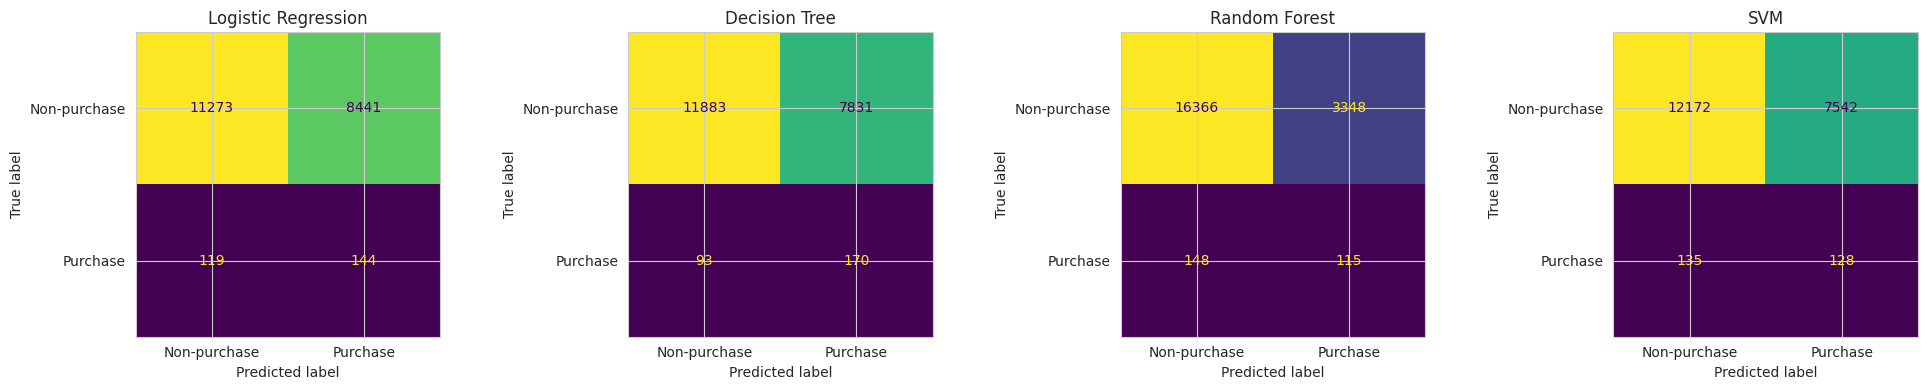

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, (pred, proba)) in zip(axes, preds_store.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Non-purchase', 'Purchase']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


### ROC Curves

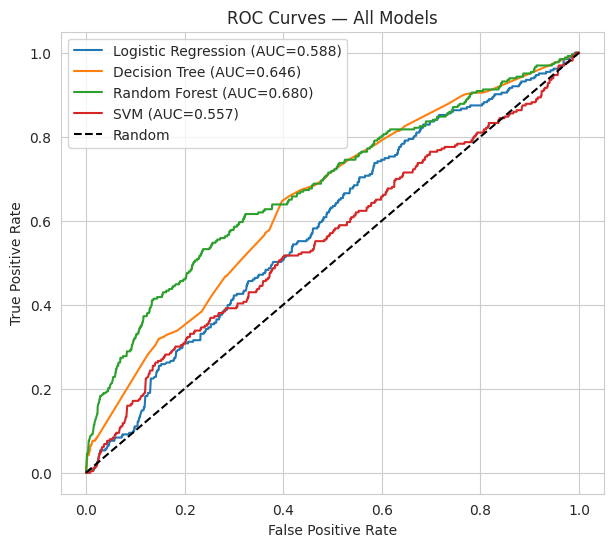

In [18]:
plt.figure(figsize=(7,6))
for name, (pred, proba) in preds_store.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.show()


### Comparison Table (sorted by ROC-AUC)

In [19]:
comparison_table.sort_values('ROC-AUC', ascending=False)


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Random Forest,0.825,0.033,0.437,0.062,0.680
Decision Tree,0.603,0.021,0.646,0.041,0.646
Logistic Regression,0.572,0.017,0.548,0.033,0.588
SVM,0.616,0.017,0.487,0.032,0.557


## 8. Customer Segmentation

Segmenting users based on their aggregated behaviour: total activity, funnel stage counts (views/carts/purchases), spend, category breadth, and session count.

In [20]:
agg = df.groupby('user_id').agg(
    total_events=('event_type', 'count'),
    num_views=('event_type', lambda x: (x == 'view').sum()),
    num_carts=('event_type', lambda x: (x == 'cart').sum()),
    num_purchases=('event_type', lambda x: (x == 'purchase').sum()),
    avg_price=('price', 'mean'),
    unique_categories=('category_main', 'nunique'),
    unique_sessions=('user_session', 'nunique'),
).reset_index()

purchase_spend = df[df['event_type'] == 'purchase'].groupby('user_id')['price'].sum().rename('total_spend')
user_df = agg.merge(purchase_spend, on='user_id', how='left')
user_df['total_spend'] = user_df['total_spend'].fillna(0)

print(user_df.shape)
user_df.head()


(21365, 9)


,user_id,total_events,num_views,num_carts,num_purchases,avg_price,unique_categories,unique_sessions,total_spend
0,275256741,1,1,0,0,1415.480000,1,1,0.0
1,306441847,2,2,0,0,164.710000,1,1,0.0
2,362699320,7,7,0,0,127.041429,1,1,0.0
3,372944259,2,2,0,0,343.380000,1,1,0.0
4,389979783,4,4,0,0,431.410000,1,1,0.0


### 8.1 Elbow Method

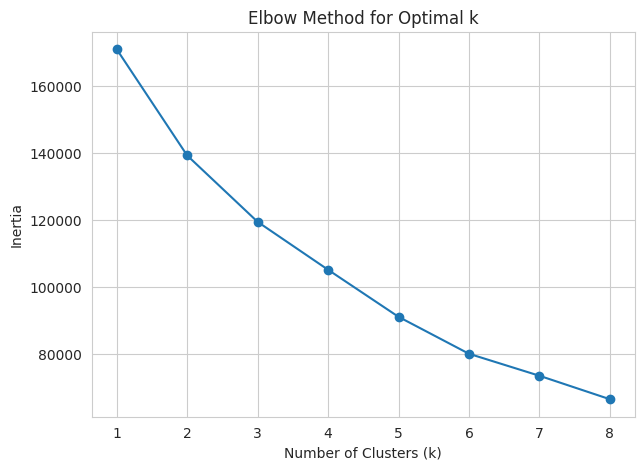

In [21]:
cluster_features = ['total_events', 'num_views', 'num_carts', 'num_purchases',
                    'avg_price', 'unique_categories', 'unique_sessions', 'total_spend']

X_cluster = user_df[cluster_features].fillna(0)
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


### 8.2 K-Means Clustering

Based on the elbow plot, k=4 gives a reasonable trade-off between simplicity and separation.

In [22]:
K_FINAL = 4
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
user_df['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

user_df['cluster'].value_counts().sort_index()


cluster
0    18500
1        1
2     2303
3      561
Name: count, dtype: int64

### 8.3 Cluster Visualizations

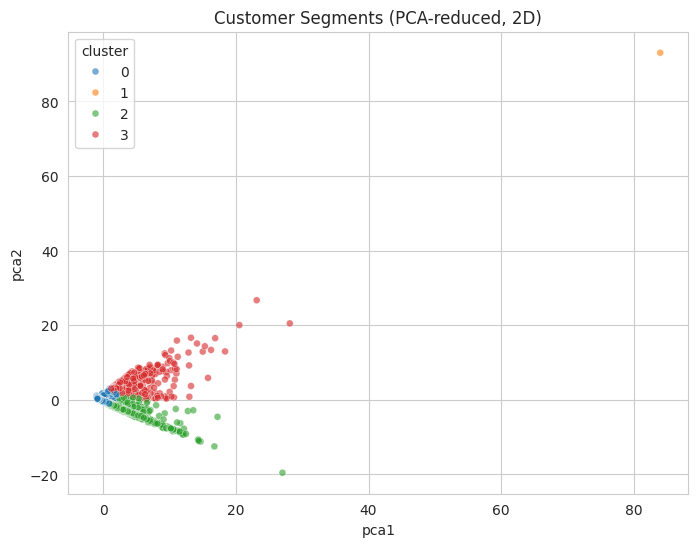

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_cluster_scaled)
user_df['pca1'], user_df['pca2'] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=user_df, x='pca1', y='pca2', hue='cluster', palette='tab10', alpha=0.6, s=25)
plt.title('Customer Segments (PCA-reduced, 2D)')
plt.show()


In [24]:
cluster_profile = user_df.groupby('cluster')[cluster_features].mean().round(2)
cluster_profile


,total_events,num_views,num_carts,num_purchases,avg_price,unique_categories,unique_sessions,total_spend
cluster,,,,,,,,
0,2.99,2.95,0.01,0.02,311.00,1.09,1.10,3.01
1,84.00,35.00,23.00,26.00,464.71,1.00,2.00,12066.53
2,17.10,17.03,0.03,0.04,264.00,1.94,1.80,4.67
3,8.99,6.44,1.21,1.34,421.19,1.19,1.39,533.48


## 9. Purchase Behaviour Analysis

### 9.1 Customer demographics
*Not applicable — no demographic fields in this dataset.*

### 9.2 Product category trends

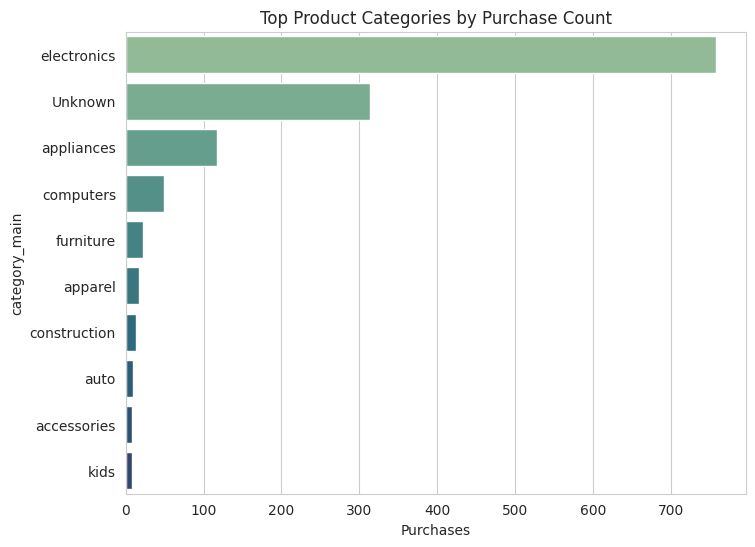

In [25]:
purchase_df = df[df['event_type'] == 'purchase']
top_purchase_categories = purchase_df['category_main'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_purchase_categories.values, y=top_purchase_categories.index, hue=top_purchase_categories.index, palette='crest', legend=False)
plt.title('Top Product Categories by Purchase Count')
plt.xlabel('Purchases')
plt.show()


### 9.3 Device preferences
*Not applicable — no device field in this dataset.*

### 9.4 Regional analysis
*Not applicable — no location/region field in this dataset.*

### 9.5 Loyalty programme analysis
*Not applicable — no loyalty field exists.* As the closest available proxy, top brands by purchase volume:

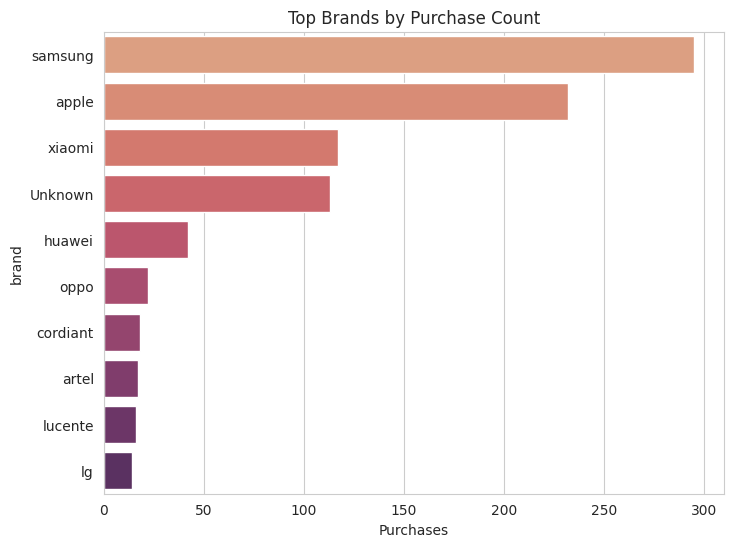

In [26]:
top_brands = purchase_df['brand'].value_counts().head(10)
plt.figure(figsize=(8,6))
sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index, palette='flare', legend=False)
plt.title('Top Brands by Purchase Count')
plt.xlabel('Purchases')
plt.show()


### 9.6 Purchase frequency

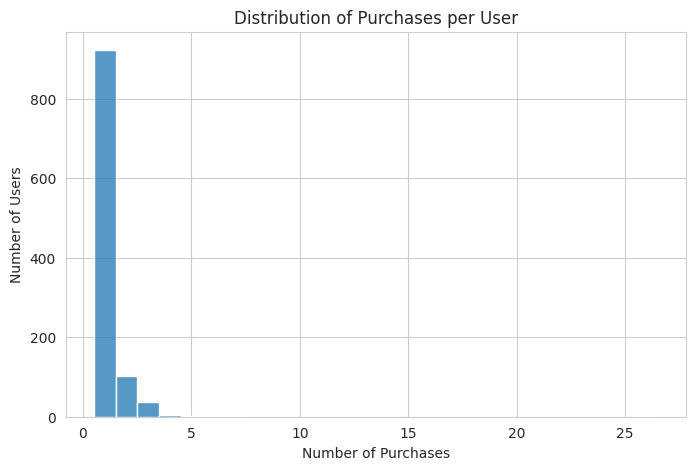

count    1073.000000
mean        1.226468
std         0.970636
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        26.000000
dtype: float64


In [27]:
purchase_freq = purchase_df.groupby('user_id').size()
plt.figure(figsize=(8,5))
sns.histplot(purchase_freq, bins=range(1, purchase_freq.max()+2), discrete=True)
plt.title('Distribution of Purchases per User')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Users')
plt.show()

print(purchase_freq.describe())


Purchases over time (daily):

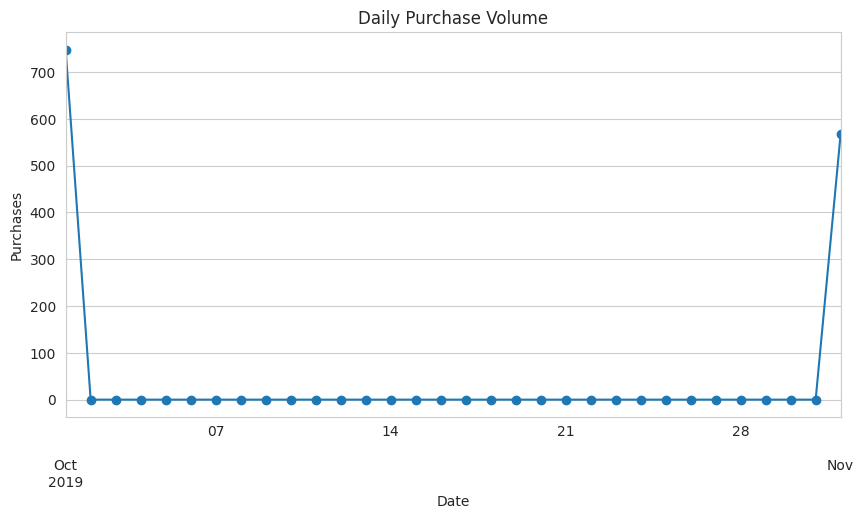

In [28]:
daily_purchases = purchase_df.set_index('event_time').resample('D').size()
plt.figure(figsize=(10,5))
daily_purchases.plot(marker='o')
plt.title('Daily Purchase Volume')
plt.ylabel('Purchases')
plt.xlabel('Date')
plt.show()


## Summary

- The dataset is a **clickstream log** (views/carts/purchases), not a customer-demographics table, so age/income/satisfaction/device/region/loyalty sections were adapted or marked not applicable rather than fabricated.
- Purchases are rare (~1.3% of events) and highly separable in some categories/brands/price ranges — see the comparison table and ROC curves in Section 7.
- Customer segmentation (Section 8) found distinct groups by activity level and spend, visualised via PCA.
- If a dataset containing the originally-requested demographic/behavioural fields becomes available, swap it in at Section 2 and the corresponding sections can be restored as specified.
